# Explore Training Data

Visualize category distribution and the rarest product categories with shelf crops and reference photos.

In [11]:
import json
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

COCO_DIR = Path("../data/coco")
PRODUCT_DIR = Path("../data/product_images")
TOP_N = 20

## Load data

In [12]:
with open(COCO_DIR / "annotations.json") as f:
    coco = json.load(f)

categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
img_id_to_info = {img["id"]: img for img in coco["images"]}

# Product metadata: name -> barcode
name_to_code = {}
meta_path = PRODUCT_DIR / "metadata.json"
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    name_to_code = {
        p["product_name"]: p["product_code"] for p in meta.get("products", [])
    }

print(f"Images: {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])}")
print(f"Categories: {len(categories)}")
print(f"Products with reference images: {len(name_to_code)}")

Images: 248
Annotations: 22731
Categories: 356
Products with reference images: 324


## Category frequency distribution

In [13]:
cat_counts = Counter(ann["category_id"] for ann in coco["annotations"])

all_cat_ids = set(categories.keys())
annotated_ids = set(cat_counts.keys())
zero_cats = all_cat_ids - annotated_ids

print(f"Total categories: {len(categories)}")
print(f"Categories with 0 annotations: {len(zero_cats)}")
print(
    f"Categories with <= 3 annotations: {sum(1 for c in cat_counts.values() if c <= 3)}"
)
print(
    f"Categories with <= 10 annotations: {sum(1 for c in cat_counts.values() if c <= 10)}"
)
print(
    f"Categories with > 100 annotations: {sum(1 for c in cat_counts.values() if c > 100)}"
)

Total categories: 356
Categories with 0 annotations: 0
Categories with <= 3 annotations: 65
Categories with <= 10 annotations: 115
Categories with > 100 annotations: 91


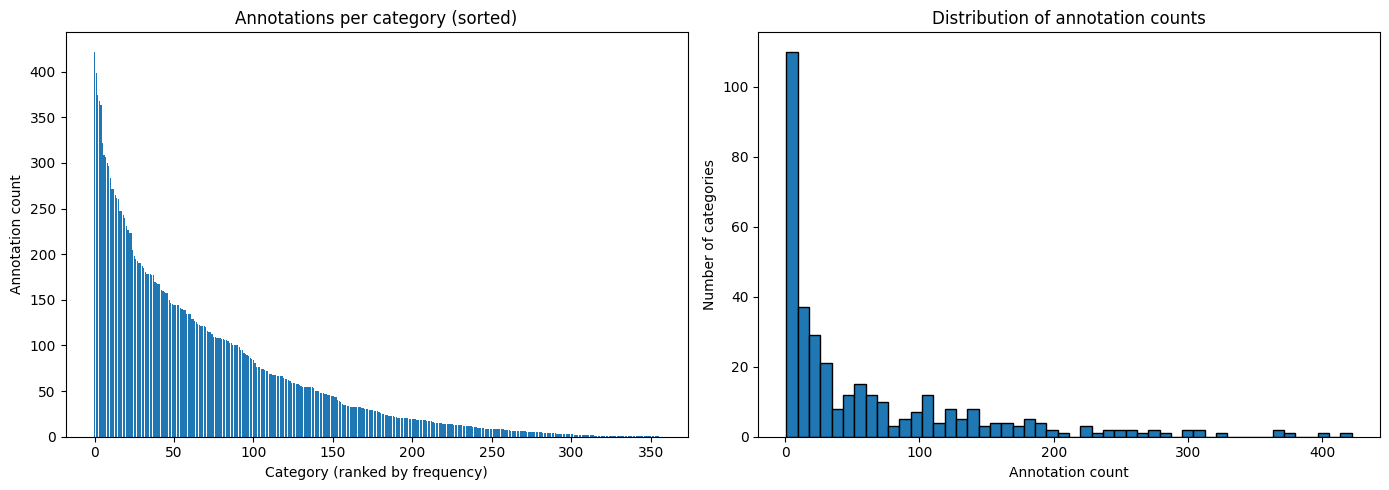

In [14]:
# Histogram of annotation counts
counts = sorted(cat_counts.values(), reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(len(counts)), counts)
ax1.set_xlabel("Category (ranked by frequency)")
ax1.set_ylabel("Annotation count")
ax1.set_title("Annotations per category (sorted)")

ax2.hist(counts, bins=50, edgecolor="black")
ax2.set_xlabel("Annotation count")
ax2.set_ylabel("Number of categories")
ax2.set_title("Distribution of annotation counts")

plt.tight_layout()
plt.show()

## Full frequency table

In [15]:
print(f"{'ID':>4}  {'Count':>5}  Name")
print("-" * 70)
for cat_id, count in cat_counts.most_common():
    print(f"{cat_id:>4}  {count:>5}  {categories[cat_id]}")

if zero_cats:
    print(f"\nCategories with 0 annotations: {sorted(zero_cats)}")

  ID  Count  Name
----------------------------------------------------------------------
 355    422  unknown_product
  86    398  HAVRE KNEKKEBRØD 300G WASA
 109    374  KNEKKEBRØD 100 FRØ&HAVSALT 245G WASA
 100    368  EVERGOOD CLASSIC FILTERMALT 250G
 349    364  KNEKKEBRØD SPORT+ 210G WASA
 246    322  HUSMAN KNEKKEBRØD 260G WASA
 296    309  FIBER BALANCE 230G WASA
 271    307  FRUKOST KNEKKEBRØD 240G WASA
 132    300  FRUKOST FULLKORN 320G WASA
 207    297  LEKSANDS KNEKKE FIBERBIT 240G
 307    283  MAISKAKER OST 125G FRIGGS
 250    271  LEKSANDS KNEKKE NORMALT STEKT 200G
  21    271  KNEKKEBRØD RUNDA SESAM&HAVSALT 290G WASA
  38    265  KNEKKEBRØD DIN STUND CHIA&HAVSALT 270G W
 280    262  RISKAKER 100G FIRST PRICE
 233    260  LEKSANDS KNEKKE GODT STEKT 200G
  96    247  FLATBRØD 275G KORNI
  92    247  KNEKKEBRØD GODT FOR DEG 235G SIGDAL
  80    243  FROKOSTEGG FRITTGÅENDE L 12STK PRIOR
 239    240  MAISKAKER CHIA/HAVSALT 130G FRIGGS
 171    231  ALI ORIGINAL FILTERMALT 250G
 

## Visualize rarest categories

For each rare category: a cropped example from a shelf image (left) and the product reference photo (right).

In [16]:
def crop_bbox(image, bbox):
    """Crop a COCO [x, y, w, h] bounding box from an image."""
    x, y, w, h = [int(v) for v in bbox]
    ih, iw = image.shape[:2]
    return image[max(0, y) : min(ih, y + h), max(0, x) : min(iw, x + w)]


# Group annotations by image
img_annotations = {}
for ann in coco["annotations"]:
    img_annotations.setdefault(ann["image_id"], []).append(ann)

# Get the N rarest categories
rarest = cat_counts.most_common()[-TOP_N:]
rarest.reverse()

for cat_id in sorted(zero_cats):
    rarest.insert(0, (cat_id, 0))
rarest = rarest[:TOP_N]

print(f"Showing {len(rarest)} rarest categories:")

Showing 20 rarest categories:


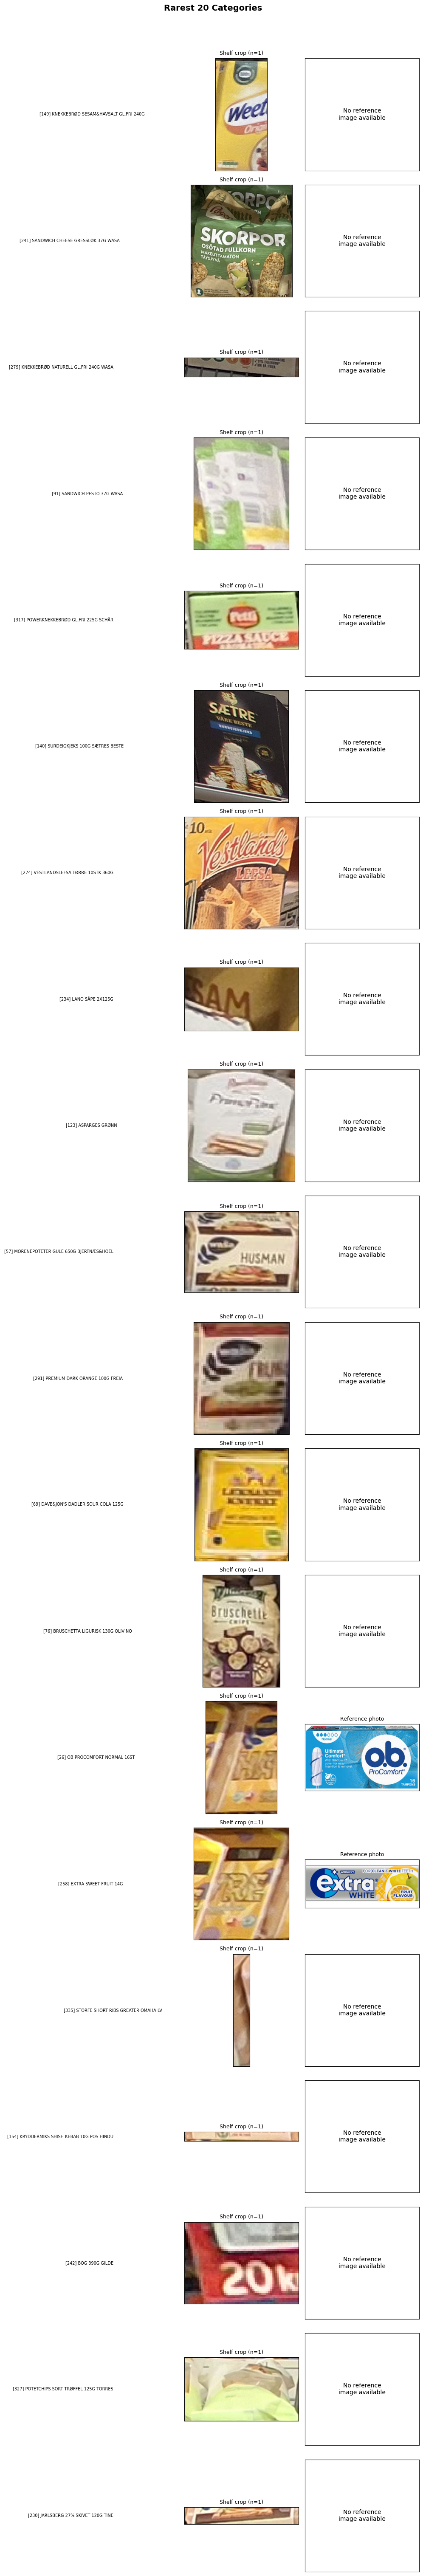

In [17]:
fig, axes = plt.subplots(len(rarest), 2, figsize=(10, 3 * len(rarest)))
if len(rarest) == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(f"Rarest {len(rarest)} Categories", fontsize=14, fontweight="bold", y=1.01)

for row_idx, (cat_id, count) in enumerate(rarest):
    cat_name = categories[cat_id]
    ax_crop = axes[row_idx, 0]
    ax_ref = axes[row_idx, 1]

    # Find a shelf crop
    shelf_crop = None
    if count > 0:
        for ann in coco["annotations"]:
            if ann["category_id"] == cat_id:
                img_info = img_id_to_info[ann["image_id"]]
                img_path = COCO_DIR / "images" / img_info["file_name"]
                if img_path.exists():
                    img = cv2.imread(str(img_path))
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        shelf_crop = crop_bbox(img, ann["bbox"])
                break

    if shelf_crop is not None and shelf_crop.size > 0:
        ax_crop.imshow(shelf_crop)
        ax_crop.set_title(f"Shelf crop (n={count})", fontsize=9)
    else:
        ax_crop.text(
            0.5, 0.5, f"No crop\n(n={count})", ha="center", va="center", fontsize=10
        )

    ax_crop.set_ylabel(
        f"[{cat_id}] {cat_name[:40]}",
        fontsize=7,
        rotation=0,
        labelpad=120,
        ha="right",
        va="center",
    )
    ax_crop.set_xticks([])
    ax_crop.set_yticks([])

    # Find reference product image
    ref_img = None
    product_code = name_to_code.get(cat_name)
    if product_code:
        ref_path = PRODUCT_DIR / product_code / "main.jpg"
        if ref_path.exists():
            ref = cv2.imread(str(ref_path))
            if ref is not None:
                ref_img = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)

    if ref_img is not None:
        ax_ref.imshow(ref_img)
        ax_ref.set_title("Reference photo", fontsize=9)
    else:
        ax_ref.text(
            0.5,
            0.5,
            "No reference\nimage available",
            ha="center",
            va="center",
            fontsize=10,
        )

    ax_ref.set_xticks([])
    ax_ref.set_yticks([])

plt.tight_layout()
plt.show()